<a href="https://colab.research.google.com/github/nitijain18/Fashion-Product-Classification-using-ResNet50-and-TensorFlow/blob/main/visual_match_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-dataset?utm_source=chatgpt.com")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:  username 
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-dataset


100%|██████████| 23.1G/23.1G [10:18<00:00, 40.0MB/s]


In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Dropout, MaxPooling2D, Conv2D, BatchNormalization
from keras.src.layers import GlobalAveragePooling2D

In [ ]:
import os

for root, dirs, files in os.walk("fashion-product-images-dataset"):
    print(root, len(files))

fashion-product-images-dataset 0
fashion-product-images-dataset/fashion-dataset 2
fashion-product-images-dataset/fashion-dataset/images 44441
fashion-product-images-dataset/fashion-dataset/styles 44446
fashion-product-images-dataset/fashion-dataset/fashion-dataset 2
fashion-product-images-dataset/fashion-dataset/fashion-dataset/images 44441
fashion-product-images-dataset/fashion-dataset/fashion-dataset/styles 44446


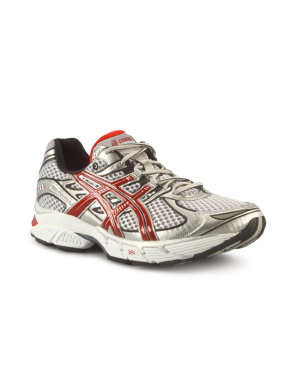

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

image_dir = "fashion-product-images-dataset/fashion-dataset/images"

sample = os.listdir(image_dir)[1129]

img = Image.open(os.path.join(image_dir, sample))

plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
#telling python which all images are there
image_paths = []

for file in os.listdir(image_dir):
    if file.endswith(".jpg"):
        image_paths.append(os.path.join(image_dir, file))

print("Total images:", len(image_paths))

print("First 5 image paths:")
for p in image_paths[:5]:
    print(p)

Total images: 44441
First 5 image paths:
fashion-product-images-dataset/fashion-dataset/images/38331.jpg
fashion-product-images-dataset/fashion-dataset/images/45597.jpg
fashion-product-images-dataset/fashion-dataset/images/10776.jpg
fashion-product-images-dataset/fashion-dataset/images/35709.jpg
fashion-product-images-dataset/fashion-dataset/images/41684.jpg


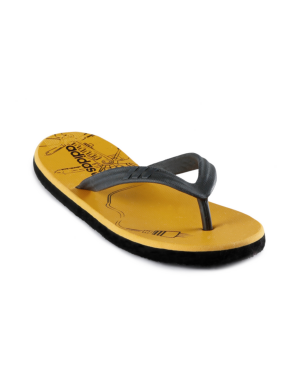

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(image_paths[100])

plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
print(img.size)

(1800, 2400)


(224, 224)


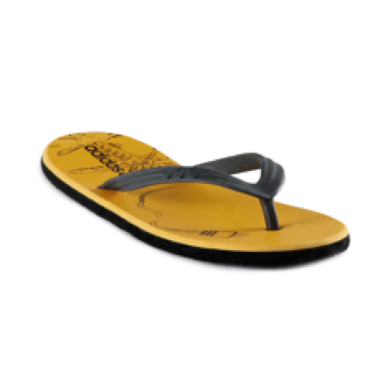

In [ ]:
img_resized = img.resize((224, 224))

print(img_resized.size)

plt.imshow(img_resized)
plt.axis("off")
plt.show()

In [ ]:
#converting image into a numpy array
import numpy as np

img_array = np.array(img_resized)

print(img_array.shape)

(224, 224, 3)


In [ ]:
print(img_array.shape)
print(img_array[0,0])

(224, 224, 3)
[255 255 255]


In [ ]:
img_array = img_array / 255.0

In [ ]:
import os
import json

styles_dir = "fashion-product-images-dataset/fashion-dataset/styles"

sample_file = os.listdir(styles_dir)[0]

print(sample_file)

with open(os.path.join(styles_dir, sample_file), "r", encoding="utf-8") as f:
    data = json.load(f)

print(data)

7013.json
{'notification': {}, 'meta': {'code': 200, 'requestId': 'e2d280b7-83c7-4466-8ec9-980ad076d74e'}, 'data': {'id': 7013, 'price': 1299, 'discountedPrice': 1299, 'styleType': 'P', 'productTypeId': 289, 'articleNumber': '40.007.32.2368 Blue', 'visualTag': '', 'productDisplayName': "s.Oliver Men's Surefunk Records Blue T-shirt", 'variantName': 'Surefunk Records Blue tee', 'myntraRating': 1, 'catalogAddDate': 1311571105, 'brandName': 's.Oliver', 'ageGroup': 'Adults-Men', 'gender': 'Men', 'baseColour': 'Blue', 'colour1': 'NA', 'colour2': 'NA', 'fashionType': 'Fashion', 'season': 'Summer', 'year': '2011', 'usage': 'Casual', 'vat': 5.5, 'displayCategories': 'Tshirts,Casual Wear and Clearance,Sale and Clearance,Casual Wear,Sale', 'weight': '0', 'navigationId': 16, 'landingPageUrl': 'Tshirts/sOliver/sOliver-Mens-Surefunk-Records-Blue-T-shirt/7013/buy', 'articleAttributes': {'Body or Garment Size': 'Garment Measurements in'}, 'crossLinks': [{'key': 'More Tshirts by s.Oliver', 'value': 'ts

In [ ]:
from keras.src import Sequential
from tensorflow.keras.applications import ResNet50
from keras.applications.resnet50 import preprocess_input

base_model = ResNet50(
    weights = 'imagenet',
    include_top = False,
    pooling = 'avg',
    input_shape = (224,224,3)
)

base_model.trainable = False

model = Sequential([
    base_model,
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(7, activation='softmax')
])
model.compile(optimizer='Adam' , loss='sparse_categorical_crossentropy' , metrics = ['accuracy'])

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,055 (91.99 MB)

 Trainable params: 526,343 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
import os
import json

styles_dir = "/content/fashion-product-images-dataset/fashion-dataset/styles"

for file in os.listdir(styles_dir):
    try:
        with open(os.path.join(styles_dir, file), "r", encoding="utf-8") as f:
            data = json.load(f)

        print(type(data["data"].get("masterCategory")))
        print(data["data"].get("masterCategory"))
        break

    except Exception as e:
        pass

<class 'dict'>
{'id': 9, 'typeName': 'Apparel', 'active': True, 'socialSharingEnabled': True, 'isReturnable': True, 'isExchangeable': True, 'pickupEnabled': True, 'isTryAndBuyEnabled': True}


In [ ]:
import os
import json
from collections import Counter

styles_dir = "/content/fashion-product-images-dataset/fashion-dataset/styles"

categories = []

for file in os.listdir(styles_dir):
    try:
        with open(os.path.join(styles_dir, file), "r", encoding="utf-8") as f:
            data = json.load(f)

        category = data["data"]["masterCategory"]["typeName"]
        categories.append(category)

    except:
        pass

counts = Counter(categories)

print("Number of classes:", len(counts))
print("\nCategories:")
print(counts)

Number of classes: 7

Categories:
Counter({'Apparel': 21400, 'Accessories': 11289, 'Footwear': 9222, 'Personal Care': 2404, 'Free Items': 105, 'Sporting Goods': 25, 'Home': 1})


In [ ]:
import os
import json

styles_dir = "/content/fashion-product-images-dataset/fashion-dataset/styles"
images_dir = "/content/fashion-product-images-dataset/fashion-dataset/images"

image_paths = []
labels = []

for file in os.listdir(styles_dir):

    try:
        with open(os.path.join(styles_dir, file), "r", encoding="utf-8") as f:
            data = json.load(f)

        category = data["data"]["masterCategory"]["typeName"]

        image_name = file.replace(".json", ".jpg")
        image_path = os.path.join(images_dir, image_name)

        if os.path.exists(image_path):
            image_paths.append(image_path)
            labels.append(category)

    except:
        pass

print("Images:", len(image_paths))
print("Labels:", len(labels))

print(image_paths[0])
print(labels[0])

Images: 44441
Labels: 44441
/content/fashion-product-images-dataset/fashion-dataset/images/7013.jpg
Apparel


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(labels)

print("First 10 labels:")
print(y[:10])

print("\nClasses:")
print(encoder.classes_)

First 10 labels:
[1 1 1 1 0 2 1 1 0 1]

Classes:
['Accessories' 'Apparel' 'Footwear' 'Free Items' 'Home' 'Personal Care'
 'Sporting Goods']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    image_paths,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("Train:", len(X_train))
print("Test :", len(X_test))

Train: 35552
Test : 8889


In [ ]:
import tensorflow as tf

def load_image(path, label):
    img = tf.io.read_file(path)

    img = tf.image.decode_jpeg(img, channels=3)

    img = tf.image.resize(img, [224, 224])

    img = img / 255.0

    return img, label

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
)

In [ ]:
train_ds = train_ds.map(load_image)

test_ds = test_ds.map(load_image)

In [ ]:
BATCH_SIZE = 32
train_ds = train_ds.batch(BATCH_SIZE)
test_ds = test_ds.batch(BATCH_SIZE)

In [ ]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32,)


In [ ]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)

Epoch 1/5
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 8677s 8s/step - accuracy: 0.8055 - loss: 0.5137 - val_accuracy: 0.8710 - val_loss: 0.3574
Epoch 2/5
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 8592s 8s/step - accuracy: 0.8720 - loss: 0.3512 - val_accuracy: 0.9076 - val_loss: 0.2756
Epoch 3/5
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 8571s 8s/step - accuracy: 0.8912 - loss: 0.3081 - val_accuracy: 0.8964 - val_loss: 0.2873
Epoch 4/5
 295/1111 ━━━━━━━━━━━━━━━━━━━━ 1:23:48 6s/step - accuracy: 0.8918 - loss: 0.2896

In [ ]:
print("Training Accuracy:",  history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
loss, accuracy = model.evaluate(test_ds)
print("Test Accuracy:", accuracy)